In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# =========================
# Yukawa potential
# =========================
def V(r):
    return -g * np.exp(-lam * r) / r

In [3]:
# =========================
# Numerov integration
# =========================
def integrate_u(E):
    f = 2.0 * (V(r) - E)              # u'' = f(r) u
    u = np.zeros_like(r)

    # For l=0 near r=0: u(r) ~ r
    u[0] = r[0]
    u[1] = r[1]

    for i in range(1, N - 1):
        c0 = 1 + h*h*f[i+1]/12
        c1 = 2*(1 - 5*h*h*f[i]/12)*u[i]
        c2 = (1 + h*h*f[i-1]/12)*u[i-1]
        u[i+1] = (c1 - c2) / c0

        # prevent overflow
        if abs(u[i+1]) > 1e100:
            u /= 1e100

    return u

In [4]:
# =========================
# Find sign-change bracket
# =========================
def find_bracket(Ea, Eb, nscan=300):
    Es = np.linspace(Ea, Eb, nscan)
    vals = [shoot(E) for E in Es]
    for i in range(len(Es) - 1):
        if vals[i] == 0:
            return Es[i], Es[i]
        if vals[i] * vals[i+1] < 0:
            return Es[i], Es[i+1]
    return None

In [5]:
# =========================
# Shooting function
# =========================
def shoot(E):
    u = integrate_u(E)
    return u[-1]

In [10]:
# =========================
# Parameters
# =========================
g = 1.5          # strength of Yukawa potential
lam = 0.5        # screening parameter
rmin = 1e-4
rmax = 50.0
N = 4000
Emin, Emax = -1.5, -1e-4   # search interval for bound-state energy
tol = 1e-6

r = np.linspace(rmin, rmax, N)
h = r[1] - r[0]

In [11]:
# =========================
# Bisection for eigenenergy
# =========================
bracket = find_bracket(Emin, Emax)
if bracket is None:
    raise RuntimeError("No bound-state bracket found. Try increasing g or changing Emin/Emax.")

Ea, Eb = bracket
for _ in range(100):
    Em = 0.5 * (Ea + Eb)
    fa, fm = shoot(Ea), shoot(Em)
    if abs(Eb - Ea) < tol:
        break
    if fa * fm <= 0:
        Eb = Em
    else:
        Ea = Em

E = 0.5 * (Ea + Eb)
u = integrate_u(E)

In [12]:
# =========================
# Normalize u(r)
# since ∫|u|^2 dr = 1
# =========================
norm = np.sqrt(np.trapezoid(u*u, r))
u /= norm
R = u / r

print(f"Ground-state estimate (n=1, l=0): E = {E:.6f}")

Ground-state estimate (n=1, l=0): E = -1.485955


<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_4284/2832018400.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi_{10}(r)$')


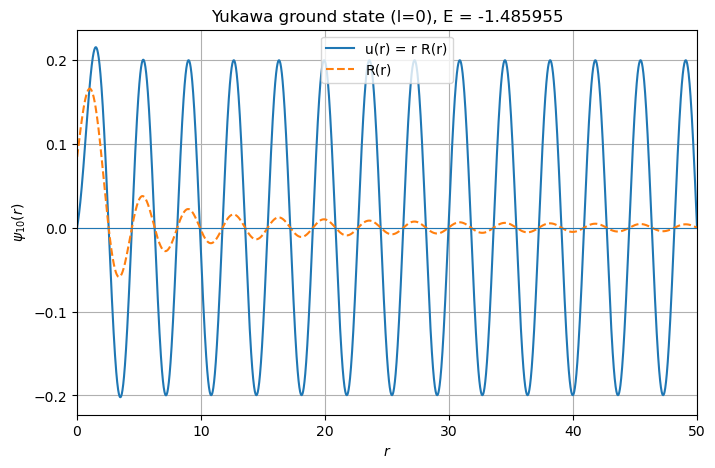

In [13]:
# =========================
# Plot u(r) and R(r)
# =========================
plt.figure(figsize=(8, 5))
plt.plot(r, u, label='u(r) = r R(r)')
plt.plot(r, R, label='R(r)', linestyle='--')
plt.axhline(0, linewidth=0.8)
plt.xlim(0, rmax)
plt.xlabel('$r$')
plt.ylabel('$\psi_{10}(r)$')
plt.title(f'Yukawa ground state (l=0), E = {E:.6f}')
plt.legend()
plt.grid(True)
plt.show()